# Customer Churn Analysis — End-to-End Machine Learning Pipeline

**Dataset:** IBM Telco Customer Churn — 7,043 customer records containing demographic, account, service, billing and churn information.

## Project objective

The objective of this project is to understand the characteristics associated with customer churn, build and compare classification models, and translate model probabilities into an operational customer-risk view that can support retention planning.

The analysis follows an end-to-end analytics workflow:

**Data quality → Exploratory Data Analysis → Feature Engineering → Train/Test Split → Preprocessing → Class-Imbalance Handling → Model Training → Model Evaluation → Model Selection → Customer Risk Scoring → Power BI Export**

A key business consideration throughout the project is that the cost of **missing a customer who is likely to churn** may be greater than the cost of contacting a customer who ultimately stays. For that reason, recall for the churn class is treated as the primary model-selection metric. The final model choice is made from the observed test-set results rather than from assumptions about which algorithm should perform best.

> **Portfolio note:** This notebook is designed to be readable as a standalone project. Each major section explains what is being done, why it matters, what the outputs show, and what the findings mean from a business perspective.


## 1. Setup & Imports

In [ ]:
# --- Core data handling ---
import numpy as np                       # numerical arrays, random number generation
import pandas as pd                      # DataFrames: the main structure we analyze/manipulate

# --- Visualization ---
import matplotlib.pyplot as plt          # base plotting library
import seaborn as sns                    # statistical plots built on matplotlib (nicer defaults)

# --- Preprocessing & pipeline ---
from sklearn.model_selection import train_test_split   # splits data into train/test sets
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # scaling + categorical encoding
from sklearn.compose import ColumnTransformer           # applies different transforms to different columns

# --- Models ---
from sklearn.linear_model import LogisticRegression      # simple, interpretable baseline classifier
from sklearn.ensemble import RandomForestClassifier       # bagged tree ensemble, handles non-linearity well
from xgboost import XGBClassifier                          # gradient-boosted tree classifier for non-linear patterns

# --- Class imbalance ---
from imblearn.over_sampling import SMOTE                 # synthetic minority oversampling technique

# --- Evaluation ---
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

# --- Reproducibility ---
RANDOM_STATE = 42                        # fixed seed so results (splits, SMOTE, models) are identical every run

# --- Plot styling (cosmetic, doesn't affect analysis) ---
sns.set_style('whitegrid')               # light gridlines, easier to read values off a chart
plt.rcParams['figure.figsize'] = (8, 5)  # sensible default figure size so we don't repeat it every cell

pd.set_option('display.max_columns', 50) # show all columns when printing wide DataFrames

print('Libraries loaded.')


Libraries loaded.


## 2. Load the Dataset

Load the IBM Telco Customer Churn CSV.


In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')   # load the real dataset — no generation step

print(f'Loaded {len(df)} rows x {df.shape[1]} columns.')
df.head()


Loaded 7043 rows x 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Quality & Target Inspection

Before modelling, we assess the structure and quality of the raw dataset. This includes checking the number of observations and variables, data types, missing values, duplicate records and the distribution of the target variable, `Churn`.

These checks are important because data-quality problems can silently propagate into later analysis. In particular, the original dataset contains blank values in `TotalCharges`, which must be interpreted correctly before the column is converted to numeric form.

### What we are looking for

- **Shape:** How many customers and variables are available?
- **Data types:** Are variables stored in formats appropriate for analysis?
- **Missing values:** Are there incomplete observations, and do they have a meaningful explanation?
- **Duplicates:** Are customers or rows duplicated?
- **Target balance:** What proportion of customers churned?

The target distribution is especially important because churn is a minority class in this dataset. This affects both model training and how performance metrics should be interpreted.


In [ ]:
df.info()   # dtype of every column + non-null counts -> quickly spots columns that look numeric but are stored as text


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum().sort_values(ascending=False)   # count of NaN per column; TotalCharges won't show here yet
                                                   # because the blanks are the string ' ', not an actual NaN


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# TotalCharges is object (string) dtype but should be numeric -> coerce it, turning unparseable
# strings (the blank ' ' rows) into actual NaN so we can see and handle them explicitly.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Rows with missing TotalCharges after coercion:', df['TotalCharges'].isnull().sum())
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head()


Rows with missing TotalCharges after coercion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN


In [ ]:
# These are all tenure == 0 customers (brand new, first bill not yet issued) -> TotalCharges
# is legitimately "not yet applicable" rather than a data error. Filling with 0 is the correct,
# defensible choice here (not the column mean, which would fabricate spend that never happened).
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print('Duplicate customerIDs:', df['customerID'].duplicated().sum())   # should be 0 -- IDs must be unique
print('Duplicate full rows:', df.duplicated().sum())                    # should be 0 in a clean dataset

df['Churn'].value_counts(normalize=True).round(3)   # class balance of the target -- this is what "imbalance" refers to later


Duplicate customerIDs: 0
Duplicate full rows: 0


,proportion
Churn,
No,0.735
Yes,0.265


### Data-quality findings

The dataset contains **7,043 customers** and no duplicate `customerID` values or duplicate rows. The main data-quality issue is **11 blank `TotalCharges` values (0.16% of the dataset)**. These observations correspond to customers with `tenure == 0`, so the blanks are consistent with customers who have not yet accumulated charges. They are therefore converted to numeric values and filled with **0**, rather than being replaced with the column mean.

The target variable is imbalanced: **26.5% of customers have churned**, while approximately 73.5% have not.

This imbalance matters because a model could achieve apparently strong accuracy simply by favouring the majority class. For example, a classifier that predicted every customer as "No Churn" would achieve roughly 73.5% accuracy while identifying **none of the actual churners**. This is why the analysis focuses on class-sensitive measures such as **recall, precision and F1-score**, and why class imbalance is addressed in the training data later in the notebook.

> **Interpretation:** The dataset is largely complete and structurally usable after a small, explainable correction to `TotalCharges`. The more important modelling consideration is the unequal distribution between churners and non-churners.


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to understand how customer characteristics differ between churners and non-churners before machine learning is introduced.

The goal is not to prove that a variable **causes** churn. Instead, EDA identifies **patterns and associations** that may be useful for modelling and that could inform customer segmentation or retention strategies.

The analysis focuses on:

1. Establishing the overall churn baseline.
2. Comparing churn rates across important categorical variables.
3. Examining how tenure and monthly charges differ between churn groups.
4. Investigating relationships between numeric variables.
5. Identifying potential redundancy or multicollinearity before feature engineering and modelling.

Each finding should therefore be interpreted as an observed relationship in this dataset, not as evidence of causation.


Overall churn rate: 26.5%


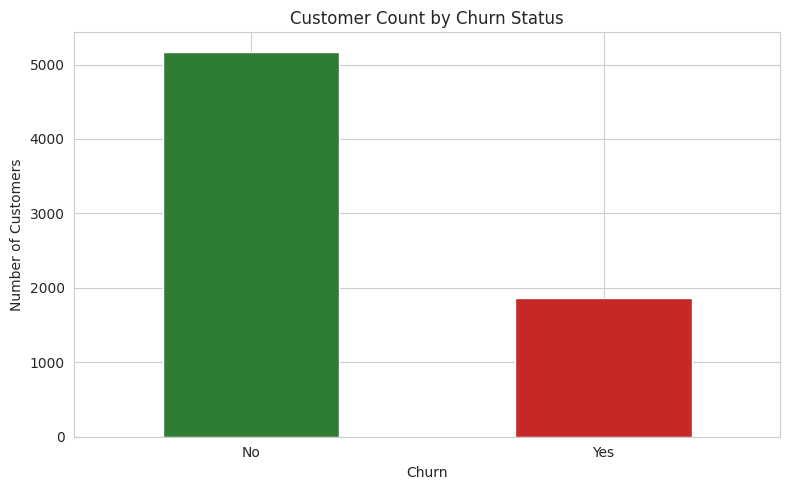

In [ ]:
# Figure 1 — Overall customer churn distribution
# The overall churn rate is the baseline against which segment-level churn rates are compared.
overall_churn_rate = (df['Churn'] == 'Yes').mean()
print(f'Overall churn rate: {overall_churn_rate:.1%}')

fig, ax = plt.subplots()
df['Churn'].value_counts().plot(kind='bar', color=['#2e7d32', '#c62828'], ax=ax)
ax.set_title('Figure 1. Overall Customer Churn Distribution')
ax.set_xlabel('Churn Status')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


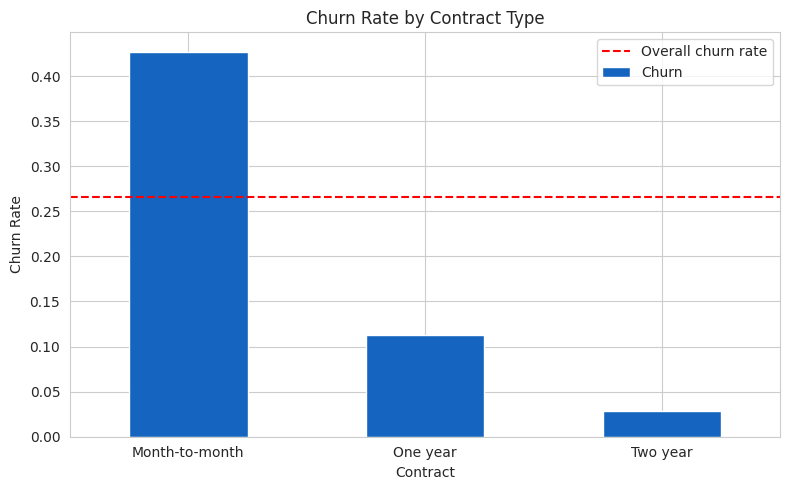

,Churn
Contract,
Month-to-month,0.427
One year,0.113
Two year,0.028


In [ ]:
# Figure 2 — Churn rate by contract type
# Contract type is compared against the overall churn baseline to identify meaningful segment differences.
contract_churn = df.groupby('Contract')['Churn'].apply(lambda s: (s == 'Yes').mean()).sort_values(ascending=False)

fig, ax = plt.subplots()
contract_churn.plot(kind='bar', color='#1565c0', ax=ax)
ax.set_title('Figure 2. Churn Rate by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate')
ax.axhline(overall_churn_rate, color='red', linestyle='--', label='Overall churn rate')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

contract_churn.round(3)


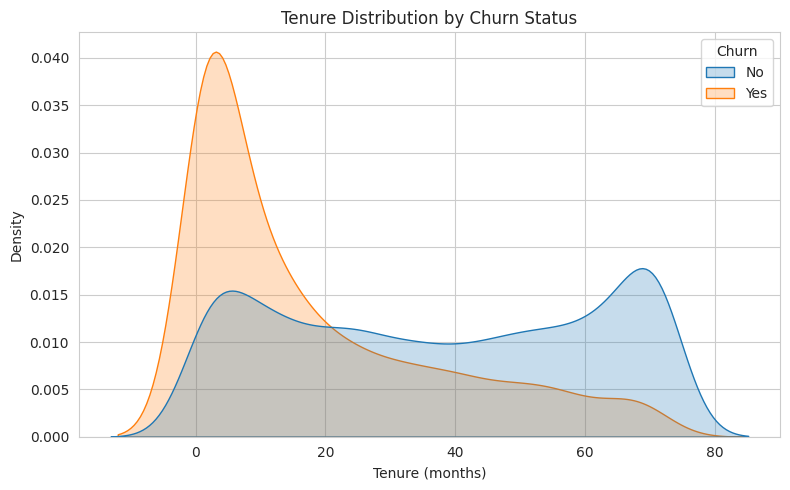

In [ ]:
# Figure 3 — Tenure distribution by churn status
# A KDE plot compares the shape of the tenure distribution for customers who churned and those who remained.
fig, ax = plt.subplots()
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, ax=ax)
ax.set_title('Figure 3. Tenure Distribution by Churn Status')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()


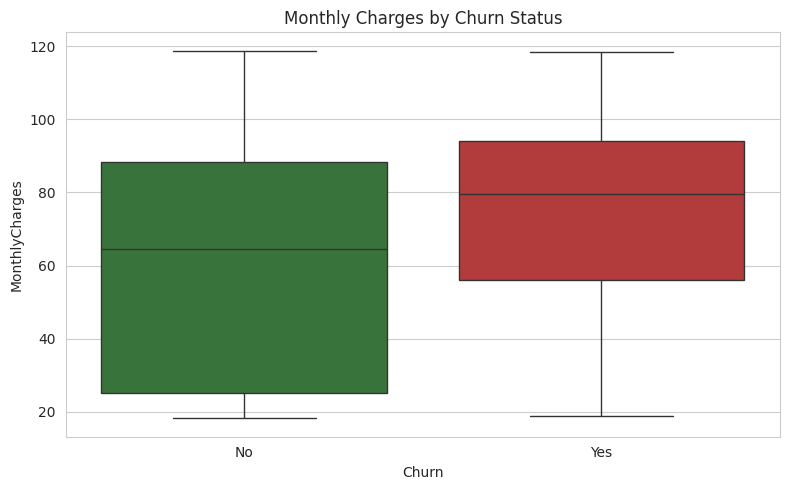

In [ ]:
# Figure 4 — Monthly charges by churn status
# The boxplot compares the median, spread and potential outliers of monthly charges across churn groups.
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax, hue='Churn', legend=False, palette=['#2e7d32', '#c62828'])
ax.set_title('Figure 4. Monthly Charges by Churn Status')
ax.set_xlabel('Churn Status')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()


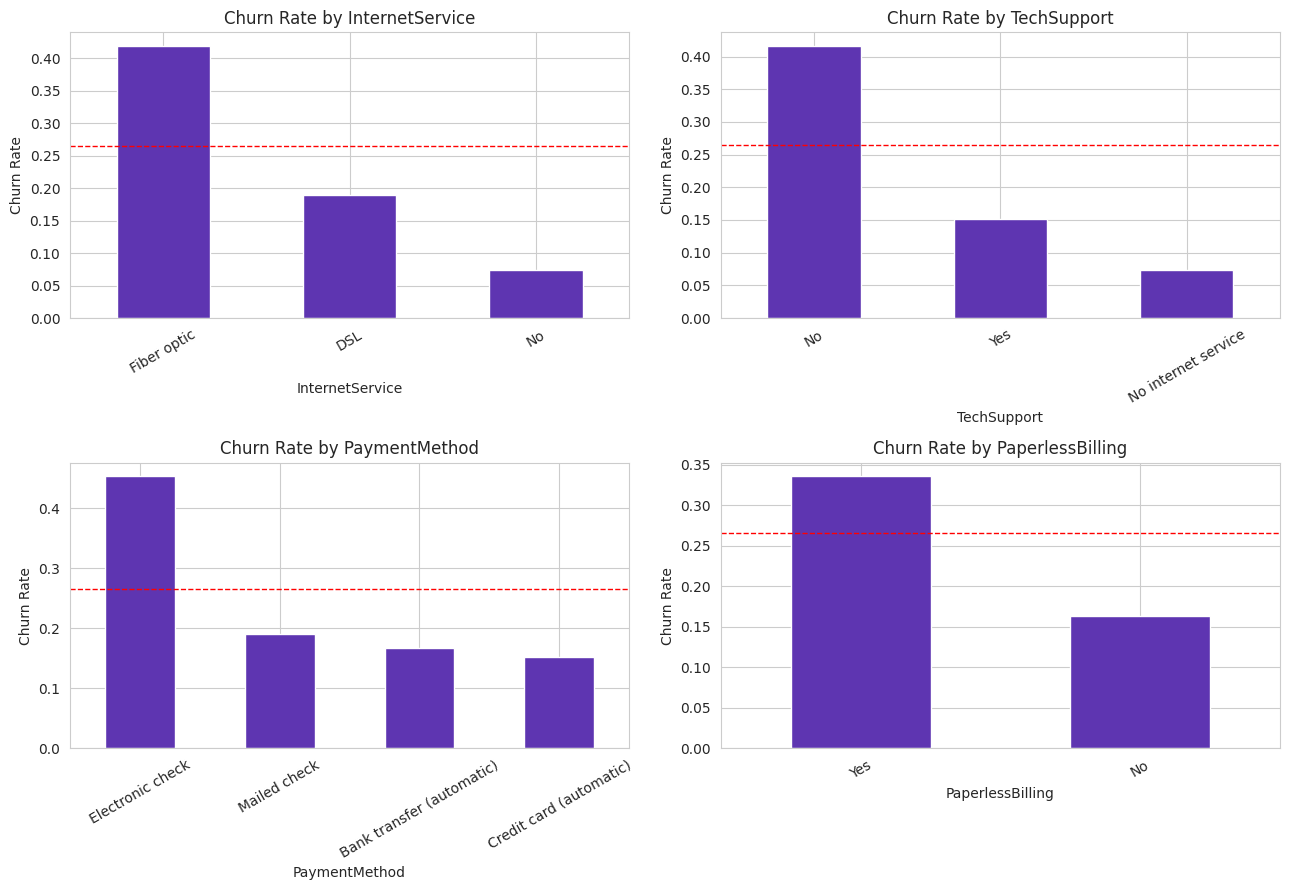

In [ ]:
# Figure 5 — Churn rate across selected service and billing features
# A four-panel view provides a compact comparison of several categorical variables.
cat_features = ['InternetService', 'TechSupport', 'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, cat_features):
    rates = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean()).sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='#5e35b1')
    ax.axhline(overall_churn_rate, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Figure 5. Churn Rate Across Selected Service and Billing Features', y=1.02)
plt.tight_layout()
plt.show()


### Figure 5 interpretation — service and billing segments

- **Internet service:** Fiber optic customers have a **41.9% churn rate**, compared with 19.0% for DSL and 7.4% for customers with no internet service. This is an association within the dataset; it should not be interpreted as evidence that fiber service itself causes churn. The higher rate may reflect differences in pricing, customer mix or service expectations.
- **Tech support:** Customers without tech support have a **41.6% churn rate**, compared with 15.2% for customers with tech support. This makes tech support an important segment for further investigation, although the analysis does not establish that adding tech support would directly reduce churn.
- **Payment method:** Electronic check has the highest observed churn rate at **45.3%**, compared with 19.1% for mailed check, 16.7% for bank transfer and 15.2% for credit card. Payment method may capture differences in customer behaviour or engagement, so it is best treated as a segmentation signal rather than a causal explanation.
- **Paperless billing:** Customers using paperless billing have a **33.6% churn rate**, compared with 16.3% for customers using paper billing. This is another useful segmentation relationship that may warrant deeper investigation.

> **Business interpretation:** These variables can help identify higher-risk customer segments, but further analysis would be required before recommending a specific intervention as a causal retention lever.


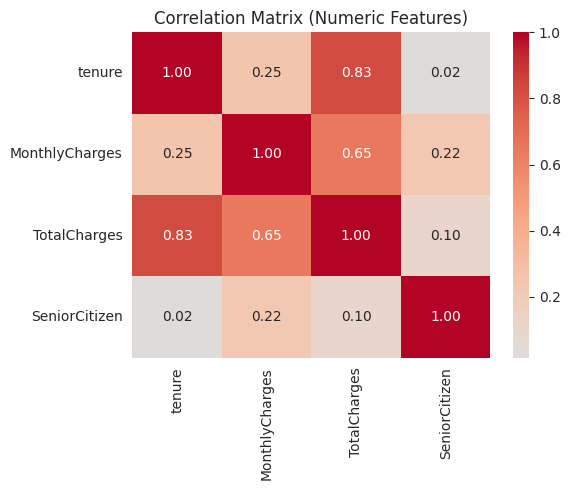

In [ ]:
# Figure 6 — Correlation matrix for numeric variables
# Correlation helps identify redundant information and potential multicollinearity,
# which is particularly relevant when interpreting linear models such as Logistic Regression.
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Figure 6. Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()


### Figure 6 interpretation — correlation and feature redundancy

`tenure` and `TotalCharges` have a correlation of **0.83**. This is expected because total charges accumulate over the length of a customer's relationship with the company.

This represents a genuine **multicollinearity consideration** for Logistic Regression: highly correlated predictors can make individual coefficient estimates less stable and harder to interpret. However, the current model specification retains both variables, so it would be inaccurate to say that multicollinearity has been removed.

The engineered `AvgMonthlySpend` feature provides an alternative, normalised view of spending relative to tenure, but it does **not by itself eliminate the correlation between `tenure` and `TotalCharges`**. This distinction is important when interpreting the final Logistic Regression coefficients.

> **Modelling note:** If coefficient-level interpretability becomes a major requirement, a future refinement would be to test a specification that removes one of the highly correlated variables and compare its predictive performance and coefficient stability.


### EDA takeaways

The exploratory analysis identifies several meaningful associations with churn:

- **Overall churn rate: 26.5%.** This provides the baseline for interpreting all segment-level rates.
- **Contract type:** Month-to-month customers have a **42.7% churn rate**, compared with 11.3% for one-year contracts and 2.8% for two-year contracts. This is the clearest segment difference observed in the EDA and represents an important retention segment to investigate.
- **Tenure:** Churners have a median tenure of **10 months**, compared with 38 months for retained customers. This indicates that churn is concentrated more heavily among customers earlier in their relationship.
- **Monthly charges:** Churners have a median monthly charge of **$79.65**, compared with $64.43 for retained customers. Higher observed charges are therefore associated with churn in this dataset; churn is not concentrated only among lower-paying customers.
- **Service and billing variables:** Internet service, tech support, payment method and paperless billing all show meaningful differences in observed churn rates and are therefore useful candidates for modelling and segmentation.
- **Numeric redundancy:** `tenure` and `TotalCharges` have a correlation of **0.83**, so their overlapping information should be considered when interpreting linear-model coefficients.

> **Important interpretation rule:** These are associations observed in the dataset, not causal claims. The purpose of EDA is to identify useful patterns for modelling and business investigation.


## 5. Feature Engineering

Feature engineering transforms raw variables into representations that may be more useful for modelling or business interpretation.

Three customer-level features are created:

1. **`TenureGroup`** — groups customers into meaningful relationship stages.
2. **`NumAddonServices`** — summarises the number of optional services subscribed to.
3. **`AvgMonthlySpend`** — normalises total charges by tenure to provide an alternative spending measure.

A separate **`ChurnFlag`** variable is created as the binary target (`1 = churn`, `0 = no churn`) required by the classification algorithms.

Feature engineering should be purposeful: each derived variable should have a clear interpretation and a reason for potentially adding information beyond the raw columns.


In [ ]:
# --- Tenure buckets: models sometimes capture non-linear tenure effects (e.g. cliff at 12 months)
# better with discrete bins than a single continuous number.
df['TenureGroup'] = pd.cut(
    df['tenure'], bins=[-1, 6, 12, 24, 48, 72],
    labels=['0-6mo', '7-12mo', '13-24mo', '25-48mo', '49-72mo']
)

# --- Count of add-on services subscribed: a single "engagement depth" score summarizing
# six separate Yes/No columns into one interpretable number (more add-ons = more invested customer).
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumAddonServices'] = (df[addon_cols] == 'Yes').sum(axis=1)

# --- Average revenue per month of tenure: normalizes TotalCharges by how long they've been a
# customer, avoiding the trivial correlation with tenure noted in the EDA takeaways above.
df['AvgMonthlySpend'] = np.where(df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges'])

# --- Binary target: models need Churn as 0/1, not the strings 'Yes'/'No'.
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

df[['tenure', 'TenureGroup', 'NumAddonServices', 'AvgMonthlySpend', 'Churn', 'ChurnFlag']].head()


,tenure,TenureGroup,NumAddonServices,AvgMonthlySpend,Churn,ChurnFlag
0,1,0-6mo,1,29.850000,No,0
1,34,25-48mo,2,55.573529,No,0
2,2,0-6mo,2,54.075000,Yes,1
3,45,25-48mo,3,40.905556,No,0
4,2,0-6mo,0,75.825000,Yes,1


In [ ]:
# Define the feature set we'll feed to the models, split by type so we can preprocess each
# type correctly (numeric features get scaled, categorical features get one-hot encoded).
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumAddonServices', 'AvgMonthlySpend']

categorical_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup'
]

X = df[numeric_features + categorical_features]   # feature matrix
y = df['ChurnFlag']                                 # target vector

print('Feature matrix shape:', X.shape)


Feature matrix shape: (7043, 22)


## 6. Train/Test Split

The dataset is divided into **80% training data and 20% test data before any learned preprocessing or resampling takes place**.

This ordering is critical for preventing data leakage. If the test set were used to learn scaling parameters, category representations or synthetic training examples, information from supposedly unseen customers could influence the model-development process and produce overly optimistic evaluation results.

`stratify=y` is used so that the training and test sets preserve approximately the same churn proportion as the original dataset.

The resulting split contains:

- **5,634 training observations**
- **1,409 test observations**
- Approximately **26.5% churn in both sets**


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # hold back 20% of customers purely for evaluation
    random_state=RANDOM_STATE,  # reproducible split
    stratify=y               # preserve the same churn/no-churn ratio in both train and test sets
)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Train churn rate:', y_train.mean().round(3), '| Test churn rate:', y_test.mean().round(3))


Train shape: (5634, 22) | Test shape: (1409, 22)
Train churn rate: 0.265 | Test churn rate: 0.265


## 7. Preprocessing

`ColumnTransformer` applies different preprocessing operations to numeric and categorical variables within a single transformation object.

- **Numeric variables:** `StandardScaler` standardises the variables so that their magnitudes are comparable. This is particularly relevant for Logistic Regression.
- **Categorical variables:** `OneHotEncoder(handle_unknown='ignore')` converts categorical values into numerical indicator columns and prevents unexpected categories at scoring time from causing a transformation error.

The transformer is **fitted only on the training data** and then applied to both the training and test sets. This means that learned quantities such as scaling means and standard deviations come exclusively from the training data.

> **Implementation note:** This notebook uses a `ColumnTransformer` for preprocessing and then passes the transformed data into the resampling and modelling stages. Although the workflow functions as a preprocessing pipeline conceptually, the code does not wrap these steps in a single sklearn `Pipeline` object.


In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),                              # standardize numeric columns (mean=0, std=1)
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)      # ignore=unseen categories at inference time won't crash the pipeline
])

# Fit the preprocessor on TRAINING data only, then transform both sets with those learned
# parameters (e.g. the scaler's mean/std come from train, never from test).
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Processed train shape:', X_train_processed.shape)   # column count grows due to one-hot encoding


Processed train shape: (5634, 53)


## 8. Handling Class Imbalance with SMOTE

Churners represent only about **26.5%** of the original dataset. Without addressing this imbalance, a model may favour the majority class and achieve reasonable accuracy while failing to identify enough actual churners.

**SMOTE (Synthetic Minority Over-sampling Technique)** addresses this by generating synthetic minority-class observations between existing minority-class examples rather than simply duplicating the same rows.

### Correct data-leakage order

SMOTE is applied **only to the training data** and never to the test data. The test set must retain the original class distribution because it is intended to represent unseen real-world customers.

This means:

**Original data → Train/Test split → Fit preprocessing on training data → Transform training data → SMOTE training data → Train models → Evaluate on untouched test data**

> **Methodological limitation:** Standard SMOTE is being applied after one-hot encoding. In this representation, categorical variables are binary indicator columns, so interpolation can create fractional values in the encoded categorical space. A more rigorous future implementation would use `SMOTENC` while categorical variables are still represented as categorical features, or compare SMOTE with model-level class weighting.


In [ ]:
print('Before SMOTE:', y_train.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print('After SMOTE:', pd.Series(y_train_resampled).value_counts().to_dict())


Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


**What SMOTE did here:** the training set went from 4,139 "No churn" vs. 1,495 "Churn"
(a ~2.8:1 imbalance) to a balanced 4,139 vs. 4,139. Note the **test set is untouched** — it
still reflects the real 73.5%/26.5% split, which is what Section 10's evaluation numbers are
measured against. If the test set had also been balanced, every metric below would look
artificially better than what the model would actually achieve on new customers.


## 9. Model Training

Three different classification approaches are trained to compare interpretability, flexibility and predictive performance:

- **Logistic Regression** — an interpretable linear classifier that provides coefficients describing how features are associated with the log-odds of churn. It provides a strong, transparent baseline.
- **Random Forest** — an ensemble of decision trees that can model non-linear relationships and interactions without requiring the analyst to specify those relationships manually.
- **XGBoost** — a gradient-boosting algorithm that builds trees sequentially, with later trees attempting to correct previous errors. It is included to test whether a more flexible boosting approach improves performance on this dataset.

The models are trained using the **SMOTE-balanced training set**. The test set remains untouched and is reserved for final evaluation.

No model is assumed to be the winner in advance. The production choice is made after comparing the models against the business-priority metrics defined in the evaluation section.


In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)   # max_iter raised so the solver reliably converges
log_reg.fit(X_train_resampled, y_train_resampled)
print('Logistic Regression trained.')


Logistic Regression trained.


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,        # number of trees -- more trees = more stable predictions, at a compute cost
    max_depth=10,             # caps tree depth to reduce overfitting on the training data
    min_samples_leaf=5,       # requires at least 5 samples per leaf, another overfitting guard
    random_state=RANDOM_STATE,
    n_jobs=-1                 # use all available CPU cores to train faster
)
rf.fit(X_train_resampled, y_train_resampled)
print('Random Forest trained.')


Random Forest trained.


In [ ]:
xgb = XGBClassifier(
    n_estimators=300,          # number of boosting rounds (sequential trees)
    max_depth=4,                 # shallower trees than RF -- boosting compounds many weak learners, so each stays simple
    learning_rate=0.05,          # step size shrinkage; smaller = more conservative updates, needs more trees to compensate
    subsample=0.8,                # each tree trains on 80% of rows (row sampling) -- reduces overfitting
    colsample_bytree=0.8,         # each tree considers 80% of columns -- decorrelates trees, like RF's feature bagging
    eval_metric='logloss',        # metric XGBoost tracks internally during training
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train_resampled, y_train_resampled)
print('XGBoost trained.')


XGBoost trained.


## 10. Model Evaluation

All models are evaluated on the **untouched test set**, which retains the original 73.5%/26.5% class distribution. This provides the most realistic estimate of how the models perform on unseen customers from the same underlying population.

### Metrics used

- **Recall (Churn):** Of the customers who actually churned, what proportion did the model identify? This is the primary metric because a false negative represents a churner who was not targeted.
- **Precision (Churn):** Of the customers flagged as likely to churn, what proportion actually churned? This matters when retention interventions have a meaningful cost.
- **F1-score (Churn):** The harmonic mean of precision and recall, useful for evaluating the balance between the two.
- **ROC-AUC:** Measures how well the model ranks churners above non-churners across classification thresholds. It is useful for comparing overall discrimination independently of one fixed threshold.
- **Accuracy:** The proportion of all test observations classified correctly. It is reported for completeness but is not the primary selection criterion because of class imbalance.

### Business interpretation

The model-selection objective is deliberately defined before looking at the comparison results:

> **Primary objective: maximise recall for the churn class, subject to the precision trade-off being acceptable for the retention programme.**

This reflects a situation where missing a genuine churner may be more costly than contacting a customer who ultimately remains.


In [ ]:
models = {'Logistic Regression': log_reg, 'Random Forest': rf, 'XGBoost': xgb}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_processed)                        # hard class predictions (0/1)
    y_proba = model.predict_proba(X_test_processed)[:, 1]            # probability of churn (class 1) -- needed for AUC/ranking

    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        'AUC': auc,
        'Precision (Churn)': report['1']['precision'],
        'Recall (Churn)': report['1']['recall'],
        'F1 (Churn)': report['1']['f1-score'],
        'Accuracy': report['accuracy']
    }

    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f'ROC-AUC: {auc:.3f}\n')

results_df = pd.DataFrame(results).T.round(3)
results_df


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.843

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.55      0.69      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409

ROC-AUC: 0.841

--- XGBoost ---
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.59      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0

,AUC,Precision (Churn),Recall (Churn),F1 (Churn),Accuracy
Logistic Regression,0.843,0.510,0.794,0.621,0.743
Random Forest,0.841,0.553,0.687,0.613,0.769
XGBoost,0.843,0.586,0.599,0.593,0.781


### Reading the model comparison

The results demonstrate why model selection should be driven by the **business objective**, rather than by model complexity or a single headline metric.

XGBoost achieves the highest **accuracy (78.1%)** and **precision (58.6%)**, while its ROC-AUC of **0.843** is tied with Logistic Regression. However, XGBoost identifies only **59.9% of the actual churners** at the default 0.5 classification threshold.

Logistic Regression identifies **79.4% of actual churners**, compared with 68.7% for Random Forest and 59.9% for XGBoost. Its trade-off is lower precision (**51.0%**), meaning that more customers are flagged as potential churn risks who ultimately do not churn.

Because this project explicitly prioritises **recall**, Logistic Regression is the appropriate model under the stated business objective. This does not mean that Logistic Regression is universally better than XGBoost. If retention interventions were expensive, precision might receive greater weight and the preferred model could change.

> **Key lesson:** The best model is not necessarily the most complex model or the model with the highest accuracy. It is the model whose performance profile best matches the business cost of different types of prediction errors.


In [ ]:
# Select the production model based on the metric Section 10 identified as the priority:
# recall on the churn class, not accuracy or AUC. This is a deliberate, data-driven choice —
# see the interpretation above for why the highest-AUC model (XGBoost) is NOT the best fit here.
best_model_name = results_df['Recall (Churn)'].idxmax()
best_model = models[best_model_name]

print(f"Selected for production scoring: {best_model_name}")
print(f"  Recall (Churn):    {results_df.loc[best_model_name, 'Recall (Churn)']:.3f}")
print(f"  Precision (Churn): {results_df.loc[best_model_name, 'Precision (Churn)']:.3f}")
print(f"  AUC:               {results_df.loc[best_model_name, 'AUC']:.3f}")


Selected for production scoring: Logistic Regression
  Recall (Churn):    0.794
  Precision (Churn): 0.510
  AUC:               0.843


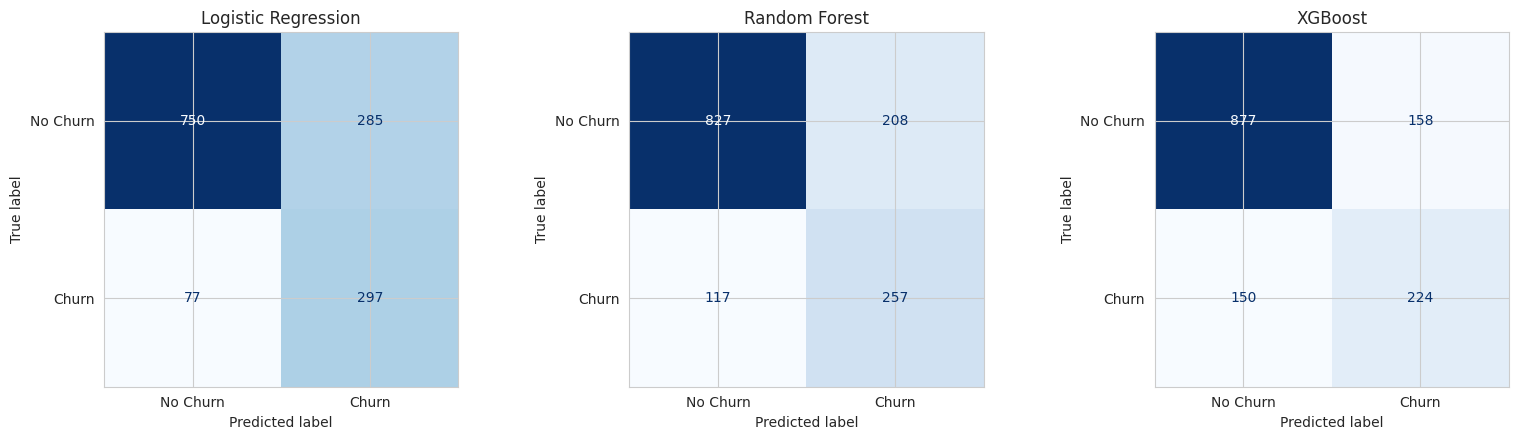

In [ ]:
# Figure 7 — Confusion matrices
# These matrices show true positives, true negatives, false positives and false negatives.
# False negatives are especially important here because they represent missed churners.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name)
fig.suptitle('Figure 7. Confusion Matrices Across Churn Models', y=1.03)
plt.tight_layout()
plt.show()


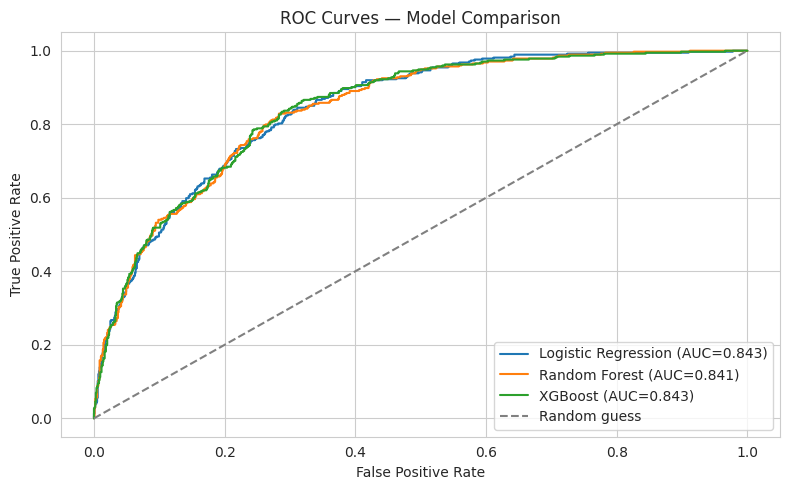

In [ ]:
# Figure 8 — ROC curves
# ROC curves show the trade-off between true-positive rate and false-positive rate
# across possible classification thresholds.
fig, ax = plt.subplots()
for name, model in models.items():
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 8. ROC Curves for Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()


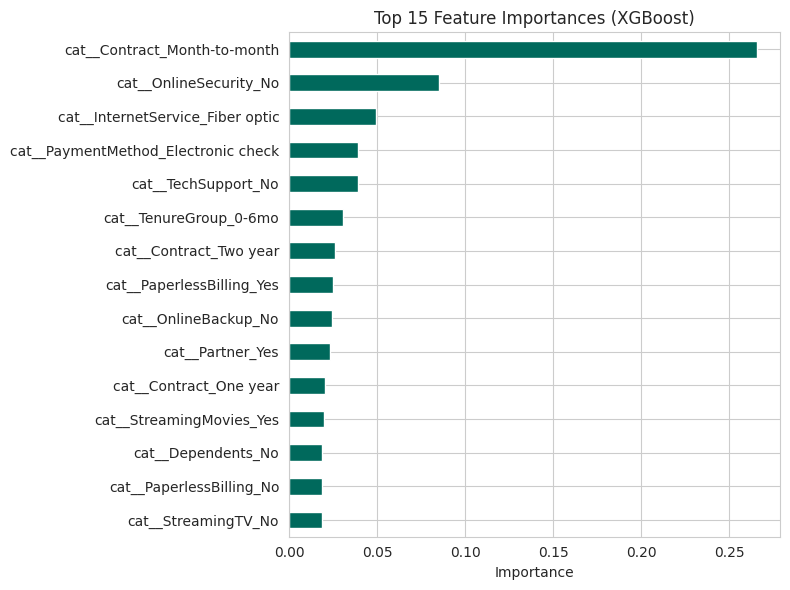

In [ ]:
# Figure 9 — XGBoost feature importance
# This is a supplementary interpretation of the tree-based model.
# Importance indicates contribution to XGBoost's predictive process, not causation.
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(
    xgb.feature_importances_, index=feature_names
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='#00695c')
ax.set_title('Figure 9. Top 15 XGBoost Feature Importances')
ax.set_xlabel('Relative Feature Importance')
ax.set_ylabel('Encoded Feature')
plt.tight_layout()
plt.show()


### Model selection and feature interpretation

The XGBoost feature-importance plot is included as a **supplementary interpretability analysis** because it provides a compact view of which variables contribute most strongly to the tree model's predictions. Feature importance should not be interpreted as proof that a variable **causes** churn, nor does it show whether the relationship is positive or negative.

For production scoring, **Logistic Regression is selected** because it achieves the highest recall for the churn class (**79.4%**) under the project's stated objective.

The selected model also offers a useful stakeholder advantage: its coefficients can be translated into directional relationships and, where appropriate, odds ratios. However, the strong correlation between `tenure` and `TotalCharges` means that individual coefficient interpretation should be treated carefully unless the feature specification is refined.

### Important threshold limitation

The reported precision and recall values use the models' **default 0.5 probability threshold**. ROC-AUC shows that the models can be compared across thresholds, but the final classification trade-off has not been optimised for a specific retention budget or intervention cost.

In a production setting, the threshold should ideally be selected using business costs:

- **False negative:** a customer who churns but is not targeted.
- **False positive:** a customer who is targeted but does not churn.

The appropriate threshold therefore depends on the cost of losing a customer, the cost of the retention intervention and the capacity of the retention team.


## 11. Scoring the Full Customer Base

The final stage converts the selected model's probability output into a customer-level risk view.

For each customer, the fitted preprocessing transformer is applied to the engineered features and Logistic Regression generates a **churn probability between 0 and 1**. This probability is then translated into three operational risk tiers:

- **Low:** below 30% predicted churn probability
- **Medium:** 30% to below 60%
- **High:** 60% or above

These thresholds are intended to make the continuous model output easier for non-technical stakeholders to interpret and prioritise.

> **Important distinction:** A churn probability is not a guarantee that a customer will churn. It is the model's estimated likelihood based on the patterns it learned from the training data.


In [ ]:
X_full_processed = preprocessor.transform(X[numeric_features + categorical_features])
df['ChurnProbability'] = best_model.predict_proba(X_full_processed)[:, 1].round(4)   # probability of churn per customer, 0-1

# Risk tiers -- turns a continuous probability into an actionable label for non-technical
# stakeholders (e.g. a retention team triaging a call list).
df['RiskTier'] = pd.cut(
    df['ChurnProbability'], bins=[-0.01, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

df[['customerID', 'Contract', 'tenure', 'MonthlyCharges', 'ChurnProbability', 'RiskTier']] \
    .sort_values('ChurnProbability', ascending=False).head(10)


,customerID,Contract,tenure,MonthlyCharges,ChurnProbability,RiskTier
1976,9497-QCMMS,Month-to-month,1,93.55,0.9644,High
4800,9300-AGZNL,Month-to-month,1,94.00,0.9640,High
1410,7024-OHCCK,Month-to-month,2,93.85,0.9640,High
6368,2720-WGKHP,Month-to-month,2,94.00,0.9634,High
3380,5178-LMXOP,Month-to-month,1,95.10,0.9633,High
3749,4424-TKOPW,Month-to-month,2,93.85,0.9631,High
3209,8149-RSOUN,Month-to-month,1,93.85,0.9625,High
5989,5567-WSELE,Month-to-month,3,94.60,0.9623,High
2577,4910-GMJOT,Month-to-month,1,94.60,0.9618,High
2208,7216-EWTRS,Month-to-month,1,100.80,0.9611,High


In [ ]:
df['RiskTier'].value_counts()   # sanity check: how many customers land in each risk tier


,count
RiskTier,
Low,3108
High,2298
Medium,1637


In [ ]:
# Figure 10 — Customer distribution by operational risk tier
# This visual translates the probability output into a simple workload view for retention teams.
risk_counts = df['RiskTier'].value_counts().reindex(['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(7, 4.5))
risk_counts.plot(kind='bar', ax=ax)
ax.set_title('Figure 10. Customer Distribution by Churn Risk Tier')
ax.set_xlabel('Risk Tier')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=0)

total_customers = risk_counts.sum()
for i, value in enumerate(risk_counts):
    ax.text(i, value + total_customers * 0.01, f'{value:,}', ha='center')

plt.tight_layout()
plt.show()


### Risk-tier interpretation

The current scoring output places:

- **3,108 customers (44.1%)** in the **Low** risk tier
- **1,637 customers (23.2%)** in the **Medium** risk tier
- **2,298 customers (32.6%)** in the **High** risk tier

The **2,298 High-risk customers** form the most immediate candidate pool for retention prioritisation under the current 60% probability threshold.

These thresholds are operational categories rather than statistically validated risk boundaries. In a production environment, they should be calibrated against historical outcomes and the capacity/cost of the retention programme.

### Evaluation versus scoring

The full-customer scoring table is useful for operational analysis, but it should not be confused with independent model evaluation. The model was trained using the training portion of the dataset, so many of the customers being scored here were also present during model fitting.

For a real deployment, the preferred workflow would be to train the final model on an appropriate historical labelled dataset and then score genuinely new/current customers whose outcomes were not available during training.


## 12. Export to Excel for Power BI

The final workbook is structured so that the machine-learning output can be used directly in a business-intelligence workflow.

The workbook contains four sheets:

### 1. `Scored_Customers`
The row-level customer dataset containing customer characteristics, churn status, predicted churn probability and risk tier. This is the primary table for filtering, segmentation and drill-down analysis.

### 2. `KPI_Summary`
A compact set of headline measures designed for dashboard cards and executive-level reporting, such as total customers, churn rate and high-risk customer counts.

### 3. `Segment_Summary`
A pre-aggregated view of churn across important customer segments, including contract type and internet service. This supports rapid comparison of higher-risk segments.

### 4. `Model_Comparison`
The evaluation results for Logistic Regression, Random Forest and XGBoost. Including this table documents why Logistic Regression was selected rather than simply presenting the final scores without context.

> **Portfolio perspective:** The export demonstrates the complete path from raw customer data to a model-informed business deliverable. The notebook performs the analytical and predictive work, while Power BI can be used to communicate the results to decision-makers.


In [ ]:
# Row-level scored data: this is the primary table Power BI will import as its data model's fact table.
export_cols = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'TenureGroup',
    'Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling', 'NumAddonServices',
    'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'Churn', 'ChurnProbability', 'RiskTier'
]
scored_export = df[export_cols].copy()

# KPI summary: single-row table of headline numbers -- feeds Power BI card visuals directly.
kpi_summary = pd.DataFrame([{
    'TotalCustomers': len(df),
    'ChurnedCustomers': int((df['Churn'] == 'Yes').sum()),
    'ChurnRate': round((df['Churn'] == 'Yes').mean(), 4),
    'AvgMonthlyCharges': round(df['MonthlyCharges'].mean(), 2),
    'AvgTenureMonths': round(df['tenure'].mean(), 1),
    'HighRiskCustomers': int((df['RiskTier'] == 'High').sum()),
    'HighRiskMonthlyRevenueAtStake': round(df.loc[df['RiskTier'] == 'High', 'MonthlyCharges'].sum(), 2)
}])

# Segment breakdown: churn rate and customer count by Contract x InternetService --
# a classic retention-strategy cut (e.g. "month-to-month + fiber" is usually the highest-risk segment).
segment_summary = (
    df.groupby(['Contract', 'InternetService'], observed=True)
      .agg(Customers=('customerID', 'count'),
           ChurnRate=('ChurnFlag', 'mean'),
           AvgMonthlyCharges=('MonthlyCharges', 'mean'))
      .reset_index()
)
segment_summary['ChurnRate'] = segment_summary['ChurnRate'].round(4)
segment_summary['AvgMonthlyCharges'] = segment_summary['AvgMonthlyCharges'].round(2)

with pd.ExcelWriter('churn_scored_data.xlsx', engine='openpyxl') as writer:
    scored_export.to_excel(writer, sheet_name='Scored_Customers', index=False)
    kpi_summary.to_excel(writer, sheet_name='KPI_Summary', index=False)
    segment_summary.to_excel(writer, sheet_name='Segment_Summary', index=False)
    results_df.to_excel(writer, sheet_name='Model_Comparison')

print('Exported churn_scored_data.xlsx with 4 sheets: Scored_Customers, KPI_Summary, Segment_Summary, Model_Comparison')


Exported churn_scored_data.xlsx with 4 sheets: Scored_Customers, KPI_Summary, Segment_Summary, Model_Comparison


## 13. Final Findings & Business Recommendations

### Executive summary

This analysis examined customer churn in the IBM Telco Customer Churn dataset and developed an end-to-end machine-learning workflow for identifying customers who may require retention attention.

The exploratory analysis found an overall churn rate of **26.5%**. The strongest observed segment differences were associated with **contract type and tenure**: month-to-month customers had a 42.7% churn rate, compared with 2.8% for two-year customers, while churners had a median tenure of 10 months compared with 38 months for retained customers. Higher monthly charges and several service and billing characteristics also showed meaningful differences between churn groups.

Three classification models were compared on an untouched test set. XGBoost produced the highest accuracy (**78.1%**) and churn precision (**58.6%**), while Logistic Regression produced the highest churn recall (**79.4%**) and the highest churn F1-score (**62.1%**). Logistic Regression and XGBoost both achieved an ROC-AUC of approximately **0.843**.

Because the project defines **recall as the primary business metric**, Logistic Regression was selected for customer scoring. This means the model is intentionally more willing to flag customers as potential churn risks in order to reduce the number of actual churners that are missed.

The selected model was then used to assign churn probabilities and operational risk tiers to the full customer base. Under the current thresholds, **2,298 customers (32.6%)** fall into the High-risk category. These customers represent a practical starting point for targeted retention analysis, although the risk thresholds should be validated against business costs and historical outcomes before production deployment.

### Recommended business actions

1. **Prioritise early-tenure customers.** The strong difference in tenure between churners and retained customers suggests that the first year of the customer relationship deserves particular attention.
2. **Investigate month-to-month customers.** Their substantially higher observed churn rate makes this segment a logical target for retention experiments and longer-term contract strategies.
3. **Investigate service and billing segments.** High-churn groups such as customers without tech support and electronic-check users should be investigated further to understand the underlying customer experience before implementing interventions.
4. **Use probability-based prioritisation.** A ranked churn probability can help retention teams focus limited resources on customers who appear most at risk rather than treating every customer equally.
5. **Optimise the intervention threshold.** The 30% and 60% risk-tier thresholds are operational choices, not validated business-optimal boundaries. A production deployment should select thresholds using intervention costs, customer value and the cost of false negatives.
6. **Monitor model performance over time.** Customer behaviour can change, so recall, precision, calibration and business outcomes should be monitored after deployment and the model retrained when performance deteriorates.

### Key limitations

- Standard SMOTE is applied after one-hot encoding, which can produce fractional values in encoded categorical features. `SMOTENC` would be a stronger future implementation.
- The Logistic Regression specification retains both `tenure` and `TotalCharges`, which are strongly correlated. This should be considered when interpreting individual coefficients.
- Model metrics use the default 0.5 classification threshold. Threshold optimisation has not been performed.
- Full-dataset risk scores include customers who were part of the training data, so these scores are intended for demonstration and segmentation rather than independent validation.
- The EDA identifies associations rather than causal relationships. Business interventions should therefore be tested rather than assumed to reduce churn.

### Final portfolio takeaway

The value of this project is not simply the final accuracy score. It demonstrates a complete analytical workflow: identifying a business problem, validating data quality, exploring customer behaviour, engineering meaningful features, controlling for class imbalance, comparing alternative models, selecting a model according to a clearly defined business objective, and translating predictions into an operational format suitable for Power BI.

